# Practical 5: Classification

## Let's get started

Ok, time for some coding. Remember the 7-step ML workflow. For the machine learning applications in the coming weeks, we will be utilizing the same structured step-wise workflow every time we apply regression, classification or clustering. This workflow requires pandas, numpy and tools for visualization (seaborn/matplotlib), so importing these libraries should always be the first step 1 after opening up spyder.

### Assignment 0: Start-up

Start up spyder, open up a new script for today's practical, import the neccesary libraries, and make sure the required dataset is in your current working directory. 

In [47]:
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Assignment 1: Data

In the next step, import and inspect the data. Today we will be working with a dataset with biomechanical data of orthopedic patients downloaded from the UCI Machine Learning repository. The dataset contains 6 biomechanical features on 310 patients that have all been manually labeled (*class*). 

First, import the csv file named 'Biomechanical_Data_UCI' as a pandas dataframe and declare it to a variable named 'df'. Next, inspect df using the .head(), .tail(), .describe(), and .info() methods in the IPython console. 

In [48]:
file_path = os.getcwd()
file_name = 'Biomechanical_Data_UCI.csv'

df = pd.read_csv(os.path.join(file_path, file_name))
df.head()
df.tail()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pelvic_incidence          310 non-null    float64
 1   pelvic_tilt numeric       310 non-null    float64
 2   lumbar_lordosis_angle     310 non-null    float64
 3   sacral_slope              310 non-null    float64
 4   pelvic_radius             310 non-null    float64
 5   degree_spondylolisthesis  310 non-null    float64
 6   class                     310 non-null    str    
dtypes: float64(6), str(1)
memory usage: 19.3 KB


,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis
count,310.000000,310.000000,310.000000,310.000000,310.000000,310.000000
mean,60.496653,17.542822,51.930930,42.953831,117.920655,26.296694
std,17.236520,10.008330,18.554064,13.423102,13.317377,37.559027
min,26.147921,-6.554948,14.000000,13.366931,70.082575,-11.058179
25%,46.430294,10.667069,37.000000,33.347122,110.709196,1.603727
50%,58.691038,16.357689,49.562398,42.404912,118.268178,11.767934
75%,72.877696,22.120395,63.000000,52.695888,125.467674,41.287352
max,129.834041,49.431864,125.742385,121.429566,163.071041,418.543082


Inspecting your dataset is essential, and the 4 functions you have just applied are able to give you a ton of essential information that you will need for later steps. If you did this right, you should be able to answer the following questions: 

:::: {important}
1. *What column contains the patient labels? We will use this column as our y-variable in the classification.*

2. *Is there any missing data we need to deal with?*

3. *What are the datatypes of our features?*

4. *Are all features measured on the same scale? If not, we might have to think about standardization later*
::::

One question we cannot answer with 100% certainty however, is what the exact labels are. Based on our inspection, we know the labels are in the 'class' column, and it seems like at least the labels 'Abnormal' and 'Normal' are present. However, as we have not inspected the full dataframe, we cannot know for sure if there are any other labels. This matters a lot because a binary classification is different from a multilabel classification. So, time to find out what we deal with. 

Apply the .unique() function to the column that has the labels in it, what do you get? 

In [49]:
df['class'].unique()

<ArrowStringArray>
['Abnormal', 'Normal']
Length: 2, dtype: str

Now we know there are only 2 labels in the dataset: 'Abnormal' and 'Normal'. Although the .unique() function is nice, it is also a bit limited, as it only tells us the labels. We might also be interested in how often a certain label occurs. To find out what labels are in a column **and** find out how often they occur at the same time, use the .value_counts() function. 

Apply this function to the class column, first without specifying any keyword arguments, then again while specifying .value_counts(normalize=True). What is the difference? 

In [50]:
print(df['class'].value_counts(), "\n")
print(df['class'].value_counts(normalize=True))

class
Abnormal    210
Normal      100
Name: count, dtype: int64 

class
Abnormal    0.677419
Normal      0.322581
Name: proportion, dtype: float64


### Assignment 2: EDA

It is going pretty well so far right? We have inspected the dataset and now know exactly what we are dealing with, that should make life a little easier. Next, it is time for some EDA (Exploratory Data Analysis). It would make no sense to set up a classification model without having some form of hypothesis about the relationships between features and labels in our data. Therefore, we need to explore our dataset to give us an idea of what to expect. 

The easiest way to do this is by visualizing the relationships between features in our dataset, and visualizing the differences between Normal and Abnormal patients on individual features. Now, there are more ways to make beautifull visualizations in Python than there are ways to Rome, so feel free to explore this if you have some spare time at the end of the practical. However, to make sure neither of you will get lost if the forest of visualizations, we will use the same method (Seaborn's .pairplot() function) you have already implemented in last weeks practical. The only difference is that we now want to plot the difference between 'Normal' and 'Abnormal' patients as well. To do this, specify hue='class' as a keyword argument. 

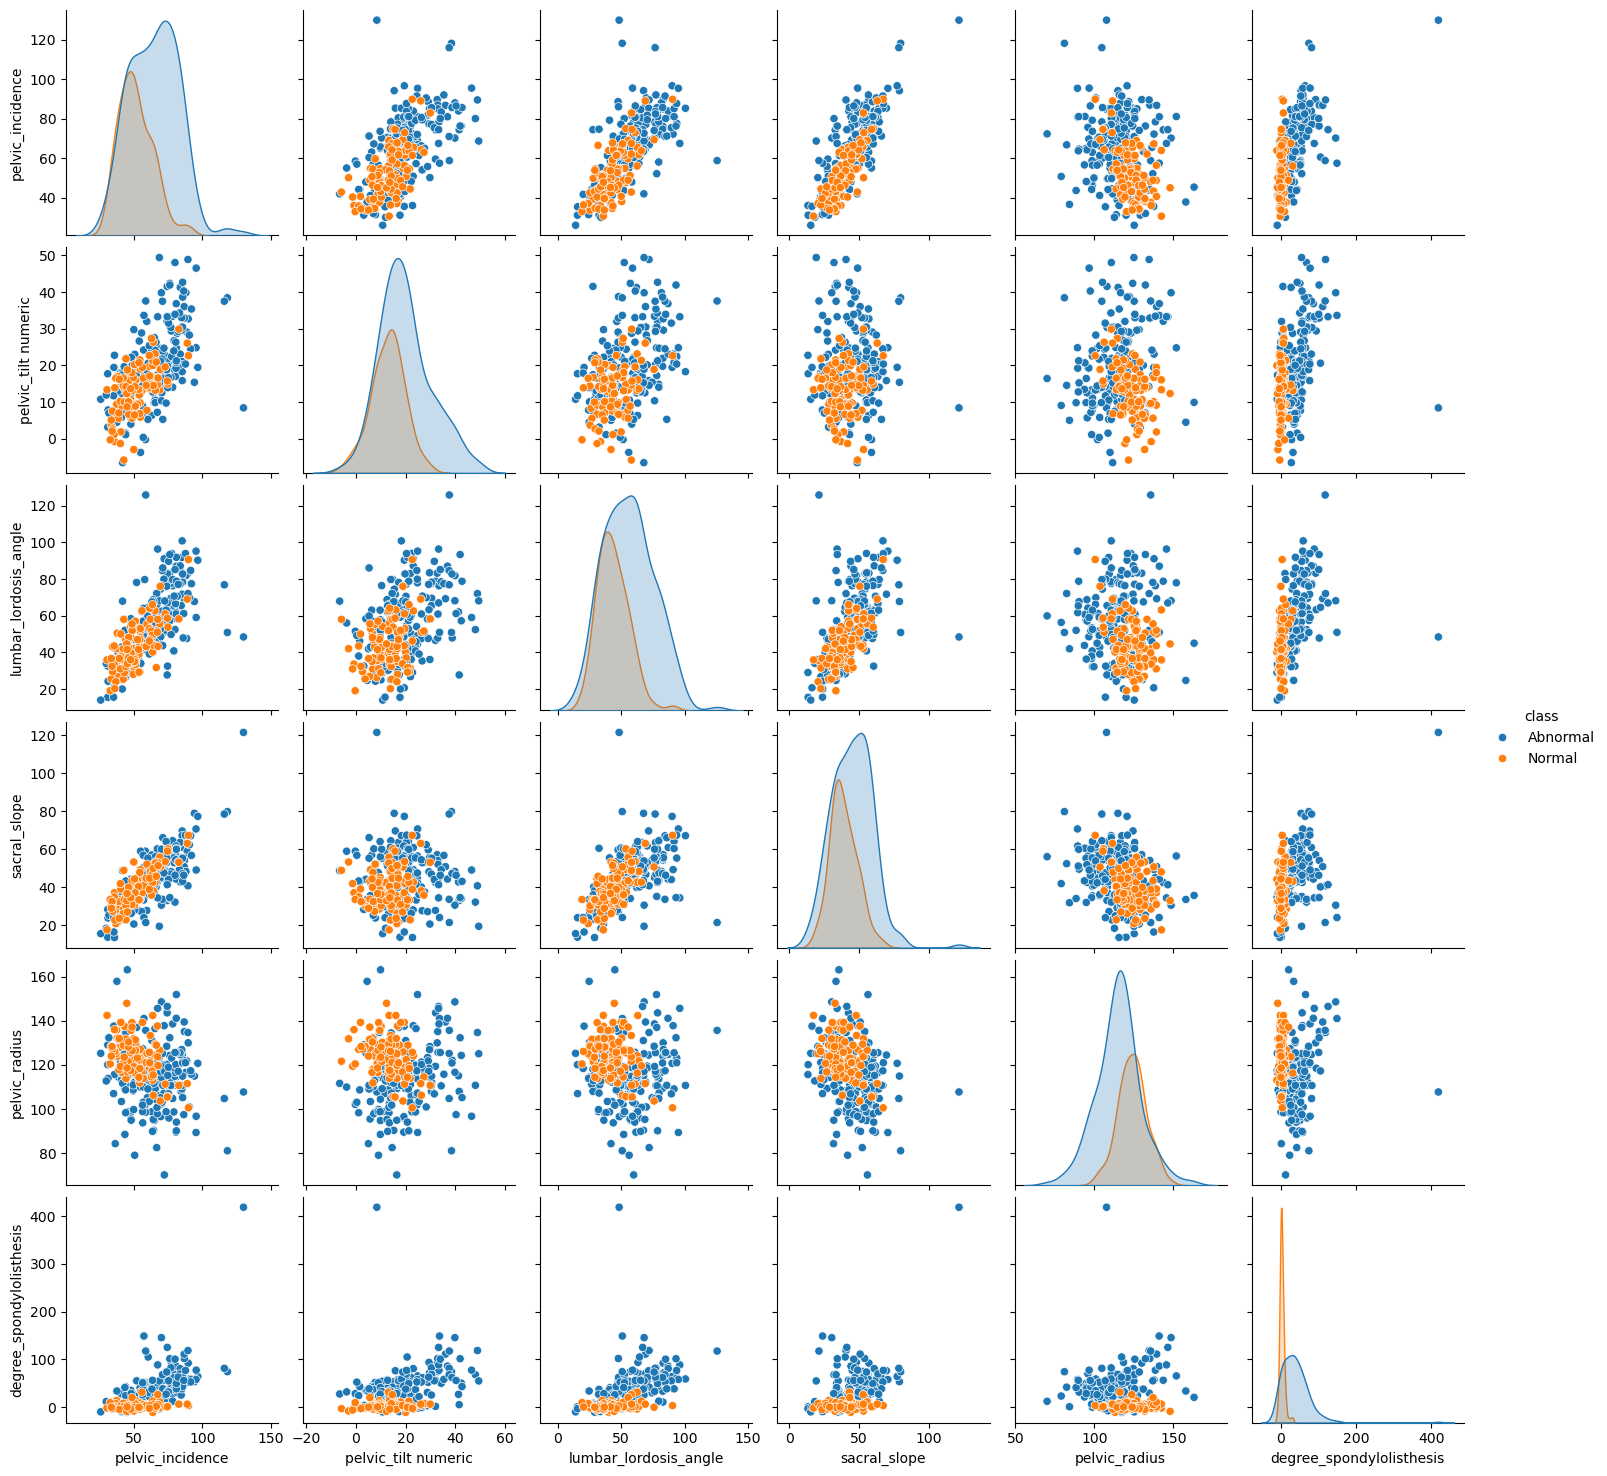

In [51]:
sns.pairplot(df, hue='class')
plt.show()

Looks pretty cool right? We could spend another hour tweaking this visualization untill it is a true work of art, but that is not the goal of today's lesson, so don't bother for now. Let's have a look at what the graphs actually tell us. 

Upon first look, it seems like there are some actual differences between Normal and Abnormal patients, so building a classificication model could actually make sense here! Also, it seems like there are some outliers in the various features, could this affect the accuracy of the model? Furthermore, it seems that our biomechanical features on average have low correlations with eachother, so it would make sense to use all 6 of them. 

We've come pretty far, so it is time for a short recap before we dive into the machine learning stuff:

```{note} 
1. We have loaded our data, put it in a nice and tidy dataframe, and we have inspected it so that we know exactly what we deal with. 

2. Based on our EDA, we expect a difference on most features between Normal and Abnormal patients, and we have also detected some outliers that might influence our model's accuracy (or not?). 
```

Now it's time to think about building a classifier. The distribution of your data influences what classifier would be most suitable for this task. This is important information, as there are dozens of possible algorithms you could work with. For today's task, we will work with a Logistic Regression Classifier, a KNN (K-nearest neighbor) classifier and a decision tree classifier. At the end of the day you should be able to pick the classifier that is most suitable for today's task. 

### Assignment 3: Model Construction

In last week's task you learned about the different steps in machine learning and the workflow of building a ML-model. Today we will be using the same workflow, though things might be a bit more complicated with today's dataset and the comparison of three different classifiers. However, don't worry too much about it, as we will again break the process down in small steps to guide you through the process. 

**Import the necessary functions**

By now, you are familiar with the sklearn library and you know how to import individual functions from sklearn's sublibraries. So we will give you a bit less detailed instructions than last week. 

Import 'LogisticRegression' from the linear_model sublibrary, 'train_test_split' & 'cross_val_score' from the model_selection sublibrary, 'StandardScaler' from the preprocessing sublibrary, 'KNeighborsClassifier' from the neighbors sublibrary, 'DecisionTreeClassifier' from the tree sublibrary,  'accuracy_score','roc_auc_score', 'roc_curve' from the metrics sublibrary

Like last week, we will tell you more about the functions and classes you don't know yet later, but let's start with importing them. 

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

**Define X and y**

First, we have to create an outcome or target variable called (by convention) `y`. This is the dependent variable (remember the labels?) we will classify. To achieve this, we will extract all values of the column containing the labeled data and put them in a variable we call `y`.

In [53]:
y = df['class']

Next, we have to create our input variable called (by convention) `X`, that is made up out of all the features or independent variables in our dataset. There are multiple ways to do this. The easiest way is by specifying all the column names of the features you want to select (remember double brackets). Declare the features to a variable called `X`.

In [54]:
X = df[['pelvic_incidence', 'pelvic_tilt numeric', 'lumbar_lordosis_angle', 
        'sacral_slope', 'pelvic_radius', 'degree_spondylolisthesis']]

**Encoding Categorical Variables**

The big difference between prediction and classification is that in prediction we work with continuous data as our `y` variable (dtype float or int), while in classification we work with labeled (categorical) data. Unfortunatly, most machine learning algorithms don't work well with categorical data when it is formatted as strings, so we have to encode the labels. In the case of binary classification like this case, we label our data with a number 0 or 1. 

Encoding can be done in many ways. For starters we could use the `.replace()` function of pandas. This functions requires a hard-coded dictionary that maps categories (labels) to a number. If we only have 2 labels like in the current case, this is pretty easy, however, if we had 100 different labels it would be pretty tedious. 

Alternatively we can use label encoding. This is also part of the pandas library and will be our method of choice. To encode the patient labels stored in `y`, we have to do a couple of things. Remember the dtype of the `'class'` column in `df`? If not check back the inspection you did in step 1. Label encoding only works with categorical data, so we have to change the dtype of `y` to categorical. 

First call `.astype('category')` on `y` to change the dtype. Make sure to declare the result back to `y`. Next, use `y.cat.codes` to change the labels in `y` to numbers. Again, make sure to declare the result back to `y`. Now print `y` to your console, did you succeed? What number represents `'Abnormal'` patients? And what number `'Normal'` patients. 

In [55]:
y = y.astype('category')
y = y.cat.codes

:::: {important} 
**The issue of scaling**
::::

Now that we defined our `X` and `y` variables, we can almost move on to fitting our classifiers. However, there is still one problem left to tackle before we can move on. Remember you inspected the dataset in step 2? We saw that our 6 features were measured on different scales (degrees, cm, mm). This is not neccesarily a problem, but it could be. 

Remember from your statistics class what a regression function looks like?

$$y=c+w_{1}X_{1} + w_{2}X_{2}$$

in which $w_{1}$ and $w_{2}$ are coefficients of features $X_{1}$ and $X_{1}$ respectively, and $c$ is the model constant or intercept. As sport & movement scientists, not only are we interested in the accuracy of such a model, but also in the importance of individual features. How much does the `'sacral_slope'` for example contribute to the patient being `'Normal'` or `'Abnormal'`? As the features are measured on different scales, differences in coefficients do not neccesarily mean anything to us. 

Even if you are not interested in the individual weights (which is a questionable decision), scaling could be crucial. As you have learned, machine learning models often optimize using gradient descent. Gradient descent tries to find the lowest location/cost in a multidimensional space. If the variables are on a different scale, the multidimensional space changes, which makes the model optimize for the variables with the biggest range, which in turn can lead to suboptimal performance of the model. 

Therefore, we have to scale all the features to the same scale (note that: first of all, not all ML models require scaling, decision tree classification models & for example deliver interpretable results without scaling. Second of all, if you do not care about coefficients but only about accuracy, scaling is not really neccesary either. It is however best practice to do so). In this case, we will be using Logistic Regression, KNN **&** Decision Trees, for Logistic Regression and KNN we will use the scaled features, for Decision Trees the unscaled features.

When we talk about scaling, we talk about transforming all features to the same scale. You might have heard of Z-scores before, and this is one way to do this, but sklearn provides multiple functions. Today we will be using the `'StandardScaler'` function, that centers and scales a feature by computing z-scores. This method assumes a normal distribution of the data, alternatively (if this assumption is violated, you could opt for `MinMaxScaler` or `RobusScaler`). 

**Train-Test-Split**

Like last week, we will use the 'train_test_split' function to create a training-set and a test-set. Because we need both scaled and unscaled X data, we will apply the train_test_split twice. 

:::: {important}
Lets evaluate the right order once again. What do you need to do first, scaling or creating a train test split? Think about it this way, your goal is to create a model that can be used in real life, with situations it has not seen before. For instance, you might want to be able to predict if a patient is in the Abnormal or Normal group next week. Your test set is a representation of this group. Your model is not allowed to see anything of this data yet, or it will result in data leakage. Since you can not scale your data based on data of a patient that will come to your practice *next week*, it is not possibly to create a scaler that includes that data *today*. Therefore, it is considered data leakage if you first scale your data, and than create a train test split.
::::

:::: {note}
**The difference between `.fit()` and `.transform()`**

In the context of Scikit-learn’s `StandardScaler()`, the `.fit()` method is used to compute the mean and standard deviation on the training data. This is necessary because scaling involves subtracting the mean and dividing by the standard deviation, so these values need to be known beforehand. Once `.fit()` has been called on the training data, the scaler has “learned” these parameters. However, `.fit()` does not change any of the data yet.

The `.transform()` method, on the other hand, is used to apply the scaling operation to the data. It uses the mean and standard deviation values that the scaler learned during the `.fit()` stage. When you call `.transform()` on the training data, it scales the data according to the parameters it learned during the `.fit()` stage. Thus, `.transforms()` does not learn itself, but uses the leared parameters and than actually transforms/changes the data you put in.

Note that `.fit_transform()` does both in one method. 
::::

Create variables called X_train, X_test, y_train, y_test by using the train_test_split function with X, y as arguments, a test_size of 30% and a random_state. Furthermore specify `stratify=y` to make sure `'Abnormal'` patients are present equally in both test and training set. 

Furthermore, create variables called X_scaled_train, X_scaled_test, y_train, y_test in the right order by using the StandardScaler function.

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
scaler.fit(X_train) 
X_train_scaled = scaler.transform(X_train) 
X_test_scaled = scaler.transform(X_test) 

Now, that works like a charm, but let's quickly break down what we actually did based on the provided key-word arguments (or kwargs):

1. We provided our scaled features and class labels because this is the data that needs to be split in a training- and a test set. 

2. We specified a `test_size`. This refers to the relative size of the test-dataset. In this case 0.3 means the test-dataset will contain 30% of the dataset, and the training-dataset will automatically contain 70% of the dataset. 

3. We specified a `random_state`. Under the hood the `train_test_split` function randomly draws from the dataset, however, by specifying a random_state we make sure that the function starts at the same location every time, so that we have a constant output if we would run our code again. 

4. We stratified the test_set on `y`, meaning there should be an equal distribution of 'Normal' and 'Abnormal' labels in test_set. This is not essential, but it could be helpfull in smaller datasets.

### Assignment 4: Model fitting

Finally, we are at the core of machine learning: Fitting a model to your data. Remember the common workflow from last week:

```{note}
1. instantiate the model function (i.e. `LogisticRegression()`) and declare it a convenient variable (i.e. `log_reg`). Specify the neccesary keyword arguments here. 

2. fit the model to your training-data by calling the `.fit()` method on the model (i.e. `log_reg.fit(X_train_scaled, y_train)`. 
```

Today we will have to instantiate three different models: `LogisticRegression`, `KNeighborsClassifier` and `DecisionTreeClassifier`. This might be the first time you hear about some of those, so let's call the help function on all 3 models to find out what keyword arguments you might need to specify when instantiating the model. Don't like the look of the documentation in the help function? Google *modelname* sklearn and you will end up in the sklearn documentation, which will give you the same information with code examples. 

Done? Some of these models look pretty complicated right? Luckily it is often best to just start with the default parameters. If you need to specify any arguments, we will tell you specifically. 

instantiate a model `log_reg` by calling `LogisticRegression()`. 
instantiate a model `knn` by calling `KNeighborsClassifier()`.
instantiate a model `tree` by calling `DecisionTreeClassifier()`.

**Predicting values in unseen data**

Now that we have a trained model, we will have to evaluate the performance of our model on the test-set. To do so, we will first predict the values in the test set by calling the `.predict()` method on our models and specifying `X_test` or `X_scaled_test` as an argument. What happens here is that we use the trained model to classify `y` ('class') for every row of data in the test-set based on the independent variables of that row. 

fit all 3 models to the data, remember to use the scaled `X` features for `log_reg` and `knn`, and the raw features for `tree`. After the models are fit, predict and print the accuracy, precision and recall of all models. This you can calculate yourself, or simply load the functions from `sklearn.metrics`. Later we will go into debt on what these scores actually represent. For now just focus the accuracy.

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

log_reg = LogisticRegression()
knn = KNeighborsClassifier()
tree = DecisionTreeClassifier()

# Again, fit is only used to learn based on the data,
# but does not actually predict or change the data.
log_reg.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
tree.fit(X_train, y_train)

# Print the results
for model, X_test_model in zip([log_reg, knn, tree], [X_test_scaled, X_test_scaled, X_test]):
    y_pred = model.predict(X_test_model)
    print(f"The performance of {type(model).__name__}:\n\tAccuracy: {round(accuracy_score(y_test, y_pred), 2)}\n\tPrecision: {round(precision_score(y_test, y_pred), 2)}\n\tRecall: {round(recall_score(y_test, y_pred), 2)}")

The performance of LogisticRegression:
	Accuracy: 0.83
	Precision: 0.75
	Recall: 0.7
The performance of KNeighborsClassifier:
	Accuracy: 0.81
	Precision: 0.66
	Recall: 0.83
The performance of DecisionTreeClassifier:
	Accuracy: 0.78
	Precision: 0.66
	Recall: 0.7


**Cross-Validation**

Splitting the dataset into a test and training set is great, but training your model on the same training set everything also brings a risk of overfitting. Therefore cross-validation is always a good idea. You have encountered the principle of cross-validation before in the lectures, and in sklearn there are many ways to do it. 

Multiple functions have a cross-validated version (like LogisticRegressionCV, RidgeRegressionCV, GridSearchCV or RandomSearchCV) that allow to specify a keyword argument cv that specifies the number of k-fold cross-validations. But there are also functions dedicated to cross-validation like the `cross_validate` function we imported today. 

`cross_validate` takes a model (called 'estimator'), the X and y (**unsplitted but preprocessed**) variables, a list of scoring variables (i.e. `['accuracy']`) and `cv=k` (number of k-fold cross-validations). It then fits the model k-times with different test and training set and returns the accuracy for every run. 

Use cross_validate on the *1 approriate model* for this approach, and print the accuracy, precision and recall. 

In [58]:
cv_tree = cross_validate(tree, X, y, cv=5, scoring=['accuracy', 'precision', 'recall'])
print(cv_tree["test_accuracy"])
print(cv_tree["test_precision"])
print(cv_tree["test_recall"])

[0.43548387 0.66129032 0.85483871 0.91935484 0.80645161]
[0.30769231 0.48148148 0.82352941 1.         0.83333333]
[0.6  0.65 0.7  0.75 0.5 ]


As you can see, there is quite some variation between the different k-folds. The first test accuracy was 45% while the 4th one was 92%. How come the differences are so big?. One problem might be a suboptimal split of the data. For instance, if there is a split where there are only 2 Abnormal cases in the train set and 200 Normal cases, the model "learns" on the train set to predict every case as Normal, but in the test set, where there are more Abnormal cases now, the performance will thus be bad, hence the 45% accuracy and the low precision. One way to solve this is to ensure that they samples are *stratified*. This basically ensures that the proportion of labels are equal of the train and test set. 

Use `StratifiedKFold()` and adapt `cv=5` to stratify the cross validation. Now redo the analysis and see if it influences the stability of the performance of the model.

In [59]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_tree = cross_validate(tree, X, y, cv=cv, scoring=['accuracy', 'precision', 'recall'])
print(cv_tree["test_accuracy"])
print(cv_tree["test_precision"])
print(cv_tree["test_recall"])

[0.74193548 0.85483871 0.80645161 0.80645161 0.85483871]
[0.6        0.73913043 0.68181818 0.68181818 0.82352941]
[0.6  0.85 0.75 0.75 0.7 ]


This prediction looks way more stable!

#### What about the logistic regression and the KNN?

Since `cross_validate` creates your train-test splits, you can not prevent data leakage with this function if you need to scale your data. If you include `X_scaled` in the `cross_validate` function, it has already learned based on the scaling parameters, and will split the data afterwards within the function. Although the functions of sklearn are often great, you lose the possibility to make small changes, like scaling after creating the train test split. 

Create your own function `scaled_cross_validation` that makes it possible to add models that need scaling, without any data leakages. Do not forget to create some nice docstrings in your function! Use your function to print the performance of the KNN and the logistic regression.

:::: {tip}
Use the `StratifiedKFold.split` and loop over each stratified fold to get the train and test indexes! 
```python
skf = StratifiedKFold(...)
for train_index, test_index in skf.split(X, y):
    X_train_fold, X_test_fold = X.loc[train_index], X.loc[test_index]
    y_train_fold, y_test_fold = y.loc[train_index], y.loc[test_index]
    ...
```
::::

In [60]:
def scaled_cross_validation(estimator, X_func, y_func, n_splits, scoring, random_state=42):
    """
    Perform scaled cross-validation using stratified k-fold.

    Args:
        estimator (object): The machine learning model to evaluate.
        X_func (pandas.DataFrame): Features (input data).
        y_func (pandas.Series): Target variable.
        n_splits (int): Number of splits for cross-validation.
        scoring (list): List of scoring metrics (possible strings are {"accuracy", "precision", "recall"}).
        random_state (int, optional): Random seed for reproducibility (default: 42).

    Returns:
        dict: A dictionary containing list of test scores for each specified metric.

    Notes:
        This function uses the following functions and classes from sklearn
            - StratifiedKFold
            - StandardScaler
            - accuracy_score
            - precision_score
            - recall_score
            
    """
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    test_scores = {f"{scorer}":[] for scorer in scoring}

    available_scorers = {
        "accuracy": accuracy_score,
        "precision": precision_score,
        "recall": recall_score,
    }

    for train_index, test_index in skf.split(X_func, y_func):
        X_train_fold, X_test_fold = X_func.loc[train_index], X_func.loc[test_index]
        y_train_fold, y_test_fold = y_func.loc[train_index], y_func.loc[test_index]

        # Scale the data after the train test split
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_test_scaled = scaler.transform(X_test_fold)

        # Predict the new, unseen data
        estimator.fit(X_train_scaled, y_train_fold)
        y_pred_fold = estimator.predict(X_test_scaled)

        # save the scores
        for score in [score for score in test_scores.keys() if score in available_scorers.keys()]:
            performance_metric = available_scorers[score]
            test_scores[score].append(performance_metric(y_test_fold, y_pred_fold))

    return test_scores



scaled_cross_validation = {
    "knn": scaled_cross_validation(knn, X, y, 5, ["accuracy", "precision", "recall"]),
    "log_reg": scaled_cross_validation(log_reg, X, y, 5, ["accuracy", "precision", "recall"]),
    "tree": {key.replace("test_", ""):value for key, value in cv_tree.items()}
}
for model_name, performance in scaled_cross_validation.items():
    print(f"{model_name} performance:")
    print("\tAccuracy: ", performance["accuracy"])
    print("\tPrecision: ", performance["precision"])
    print("\tRecall: ", performance["recall"]) 

knn performance:
	Accuracy:  [0.7741935483870968, 0.7903225806451613, 0.8064516129032258, 0.7741935483870968, 0.8870967741935484]
	Precision:  [0.6666666666666666, 0.6296296296296297, 0.7222222222222222, 0.65, 0.8421052631578947]
	Recall:  [0.6, 0.85, 0.65, 0.65, 0.8]
log_reg performance:
	Accuracy:  [0.8387096774193549, 0.8387096774193549, 0.8225806451612904, 0.9193548387096774, 0.8387096774193549]
	Precision:  [0.8125, 0.6923076923076923, 0.8, 0.8260869565217391, 0.75]
	Recall:  [0.65, 0.9, 0.6, 0.95, 0.75]
tree performance:
	Accuracy:  [0.74193548 0.85483871 0.80645161 0.80645161 0.85483871]
	Precision:  [0.6        0.73913043 0.68181818 0.68181818 0.82352941]
	Recall:  [0.6  0.85 0.75 0.75 0.7 ]


### Assignment 5: Evaluating the model

Now, let's find out how well our model performs. Last week you learned how to find out the R^2 and RMSE of a prediction model. Sadly these metrics will not do us much good in classification models. Luckily we have some alternatives. 

First of all, we are interested in the accuracy of our model: How many labels were correctly predicted by our trained model? This is pretty easy to find out, as a matter of fact, you already calculated this for the models in the stratified kfold. However, there might be other classification metrics that we might be interested in. 

Before we continue, print the average accuracy and the standard deviation of the accuracy over 5 folds for the the three models



In [61]:
for model_name, performance in scaled_cross_validation.items():
    accuracy = performance["accuracy"]
    print(f"{model_name}: mean accuracy: {np.mean(accuracy).round(3)} +- {np.std(accuracy).round(3)}")

knn: mean accuracy: 0.806 +- 0.042
log_reg: mean accuracy: 0.852 +- 0.034
tree: mean accuracy: 0.813 +- 0.042


**False Positive & False Negative**

It seems like all models perform pretty accurate right? LogisticRegression seemed to have the highest accuracy, so that is probably the best one in this case, or maybe not? 

Accuracy tells us only half the story. Classification works with probabilities to make predictions. For example: the model could predict a 'Normal' patient with 51% certainty, or with 90% certainty. In both cases the model can be right or wrong, but the certainty makes a difference right? When the model is wrong, you want certainty/confidence to be low, when the model is right, you want the model to be certain and not doubtfoul. In some ways this is comparable to our RMSE idea of a prediction, and in classification you can for example use the log loss you might have heard about in the lecture to quantify the degree of certainty. As this is too complicated for now, we will leave that for another time though. 

However, there is one more aspect of model performance we need to look into. When working with patients, you might not worry about false positives (i.e. labeling a patient as abnormal while in reality he is normal). Further diagnosis and expert evaluation by the doctor will reveal this in the end. You would however care about false negatives (i.e. Abnormal patients labeled as Normal). These patients might miss out on critical care as they were unjustly labeled as Normal. 

To find out how the models perform in that aspect, we will plot the ROC-curve of every model, and compute the AUC_ROC_SCORE. 

To be able to do this, we first need the probabilities of every prediction. We can get these the exact same way as we computed the predict values. The only difference is you have to use the `.predict_proba()` function instead of `.predict()`. Create a variable holding the prediction probabilities called 'probs_*modelname*' for all three models using the `.predict_proba()` function. `predict_proba` stands for "predict probability" and thus shows how certain/confident the model is about the classification.

In [62]:
probs_log_reg = log_reg.predict_proba(X_test_scaled)
probs_knn = knn.predict_proba(X_test_scaled)
probs_tree = tree.predict_proba(X_test)

Now use the `roc_curve` function we imported earlier with arguments `y_test` and the probabilities of the model computed in the previous step. You will have to do this for every model. The roc_curve function returns a **false positive rate**, **true positive rate** and **threshold** array. 

For every model declare the results to 3 variables like the example below:
```python
fpr_logreg, tpr_logreg, threshold_log_reg = roc_curve(y_test, probs_log_reg[:,1])
```

you specify `[:,1]` because we only need column 1 from the probability array. The first index (`0`) gives the probability for the label 0, in our case Normal, and the second index (`1`) the probability for the label 1 or Abnormal.

In [63]:
fpr_log_reg, tpr_log_reg, threshold_log_reg = roc_curve(y_test, probs_log_reg[:,1])
fpr_knn, tpr_knn, threshold_knn = roc_curve(y_test, probs_knn[:,1])
fpr_tree, tpr_tree, threshold_tree = roc_curve(y_test, probs_tree[:,1])

Now let's put those roc curves in a single plot to directly compare all three models. to achieve this we first plot the roc curves as lineplots. Specify the false positive rate on the x-axis and the true positive rate as on the y axis. Do this for all three models, also specify a label=*modelname* so we can make a nice legend.

Next, add a diagonal reference line with `linestyle='--'` that runs from `[0,0]` to `[1,1]` as a baseline reference. 

Now add a title, x-label, y-label and legend to complete the plot. 

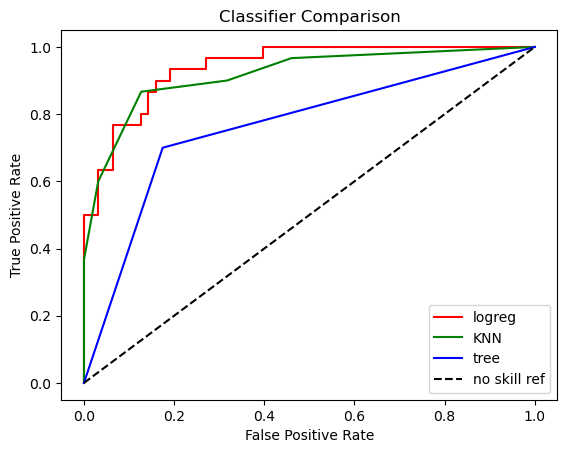

In [64]:
plt.figure()
plt.plot(fpr_log_reg, tpr_log_reg, color='red', label='logreg')
plt.plot(fpr_knn, tpr_knn, color='green', label='KNN')
plt.plot(fpr_tree, tpr_tree, color='blue', label='tree')
plt.plot([0,1], [0,1], color='black', linestyle='--', label='no skill ref')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Classifier Comparison')
plt.legend()
plt.show()

From inspecting the figure, it seems like a close call between the KNN and the logistic regression. However, we would like to quantify this. To do this, you need to compute the so-called AUC (Area Under the Curve). To do so, use the `roc_auc_score` we imported before. You need the exact same keywords as you used in `roc_curve` functions. Compute the AUC for every roc_curve and declare them to a variable called auc_*modelname* 

In [65]:
auc_log_reg = roc_auc_score(y_test, probs_log_reg[:,1])
auc_knn = roc_auc_score(y_test, probs_knn[:,1])
auc_tree = roc_auc_score(y_test, probs_tree[:,1])

Now, as a final tweak, add the AUC scores to the plot. To do so, use the plt.text method and think of a nice way to put all three values clearly in the plot. 

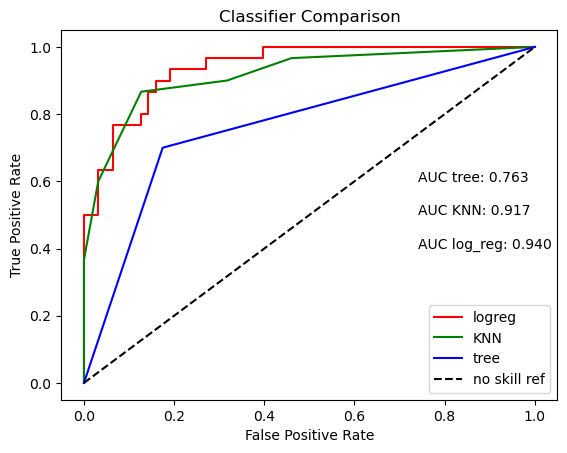

In [66]:
plt.plot(fpr_log_reg, tpr_log_reg, color='red', label='logreg')
plt.plot(fpr_knn, tpr_knn, color='green', label='KNN')
plt.plot(fpr_tree, tpr_tree, color='blue', label='tree')
plt.plot([0,1], [0,1], color='black', linestyle='--', label='no skill ref')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Classifier Comparison')
plt.legend()
plt.text(x=0.74, y=0.4, s='AUC log_reg: %.3f' % auc_log_reg)
plt.text(x=0.74, y=0.5, s='AUC KNN: %.3f' % auc_knn)
plt.text(x=0.74, y=0.6, s='AUC tree: %.3f' % auc_tree)
plt.show()

### Assignment 6: Interpreting the model

Finally, the end is near. Our model works - and after evaluation we can conclude it works quite well - and we have done some actual machine learning. Now let's interpret the model to study the importance of individual features. 

Last week you have already learned how to do this in regression models, for the logreg model this works exactly the same. Just call the logreg.coef_ and logreg.intercept_ methods and construct the regression equation. Do this first. 

Text(0, 0.5, 'manual prediction')

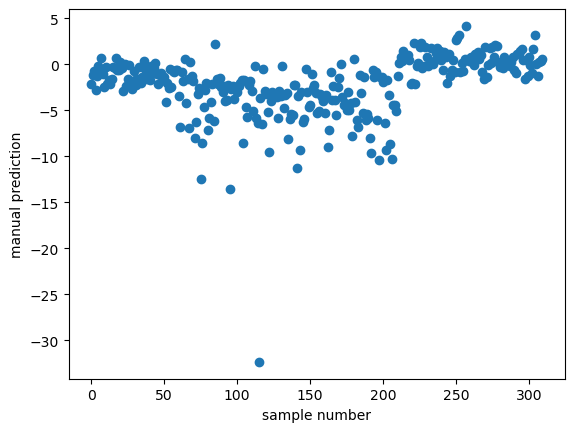

In [68]:
intercept = log_reg.intercept_
coefs = log_reg.coef_
reg_eq = 'y = -2.274 + 0.073*pelvic_incidence - 0.851*pelvic_tilt numeric + 0.327*lumbar_lordosis_angle + 0.770*sacral_slope + 1.124*pelvic_radius - 3.641*degree_spondylolisthesis'

X_scaled = pd.DataFrame(scaler.transform(X))

linear_prediction = intercept[0] \
+ coefs[0, 0] * X_scaled.iloc[:, 0] \
+ coefs[0, 1] * X_scaled.iloc[:, 1] \
+ coefs[0, 2] * X_scaled.iloc[:, 2] \
+ coefs[0, 3] * X_scaled.iloc[:, 3] \
+ coefs[0, 4] * X_scaled.iloc[:, 4] \
+ coefs[0, 5] * X_scaled.iloc[:, 5]

plt.scatter(range(len(linear_prediction)), linear_prediction)
plt.xlabel("sample number")
plt.ylabel("manual prediction")

Hey, this is weird, the values range roughly between -35 and 5. This is not a probability between 0 and 1. This is because the logistic regression model uses the logit function to transform the linear regression equation into a probability. To do so, we use a sigmoid function:
 $$y = \frac{1}{1+e^{-x}}$$

Where $x$ is the linear regression equation.

In [69]:
y_pred = 1 / (1 + np.exp(-linear_prediction)) 
y_pred.describe()

count    3.100000e+02
mean     2.823795e-01
std      2.852887e-01
min      8.983274e-15
25%      2.909026e-02
50%      1.638637e-01
75%      5.060418e-01
max      9.845849e-01
dtype: float64

**Visualizing Decision Trees**

The other two models are a bit more difficult. KNN models are not able to tells us anything about individual features, so we don't have to look into that one. But when it comes to decision trees we can get an insight in what features play a big role in the decisions that were made. You can also visualize the decision trees, but this falls outside of the scope of today's practical. 

For decision trees, you can assess the 'feature importance' of all features. We will not cover the techinical details here but the higher the feature importance, the greater the reduction of the criterion brought by a feature. 

Use the `tree.feature_importances_` method to find out about feature importance. This method will output an array with feature importances for every feature. 

In [70]:
tree.feature_importances_

array([0.04475141, 0.11619561, 0.0730806 , 0.10780075, 0.18993526,
       0.46823637])